In [47]:
from langgraph.graph import START, END, StateGraph
from typing import TypedDict, Annotated, Literal
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import SystemMessage, HumanMessage
from dotenv import load_dotenv
from pydantic import BaseModel, Field
import operator

In [48]:
load_dotenv()

True

In [59]:
generator_llm = ChatGoogleGenerativeAI(model='gemini-3.5-flash')
evaluator_llm = ChatGoogleGenerativeAI(model='gemini-3.1-pro-preview')
optimizer_llm = ChatGoogleGenerativeAI(model='gemini-3.8-flash')


In [50]:
class TweetEvaluation(BaseModel):

    evaluation: Literal["approved", "needs_improvement"] = Field(description="Final evaluation result")
    feedback: str = Field(..., description="feedback for the tweet")

In [51]:
structured_evaluator_llm = evaluator_llm.with_structured_output(TweetEvaluation)

In [52]:
class TweetState(TypedDict):

    topic: str
    tweet: str
    evaluation: Literal["approved", "need improvement"]
    feedback: str
    Iteration: int
    maxIteration: int

    tweet_history: Annotated[list[str], operator.add]
    feedback_history = Annotated[list[str], operator.add]

In [53]:
def generate_tweet(state: TweetState): 

    messages = [
        SystemMessage(content="You are a funny and clever Twitter/X influencer."),
        HumanMessage(content=f"""
Write a short, original, and hilarious tweet on the topic: "{state['topic']}".

Rules:
- Do NOT use question-answer format.
- Max 280 characters.
- Use observational humor, irony, sarcasm, or cultural references.
- Think in meme logic, punchlines, or relatable takes.
- Use simple, day to day english
""")
    ]

    response = generator_llm.invoke(messages).content

    return {'tweet': response, 'tweet_history': [response]}

In [54]:
def evaluate_tweet(state: TweetState):

    messages = [
    SystemMessage(content="You are a ruthless, no-laugh-given Twitter critic. You evaluate tweets based on humor, originality, virality, and tweet format."),
    HumanMessage(content=f"""
Evaluate the following tweet:

Tweet: "{state['tweet']}"

Use the criteria below to evaluate the tweet:

1. Originality – Is this fresh, or have you seen it a hundred times before?  
2. Humor – Did it genuinely make you smile, laugh, or chuckle?  
3. Punchiness – Is it short, sharp, and scroll-stopping?  
4. Virality Potential – Would people retweet or share it?  
5. Format – Is it a well-formed tweet (not a setup-punchline joke, not a Q&A joke, and under 280 characters)?

Auto-reject if:
- It's written in question-answer format (e.g., "Why did..." or "What happens when...")
- It exceeds 280 characters
- It reads like a traditional setup-punchline joke
- Dont end with generic, throwaway, or deflating lines that weaken the humor (e.g., “Masterpieces of the auntie-uncle universe” or vague summaries)

### Respond ONLY in structured format:
- evaluation: "approved" or "needs_improvement"  
- feedback: One paragraph explaining the strengths and weaknesses 
""")
]

    response = structured_evaluator_llm.invoke(messages)

    return {'evaluation':response.evaluation, 'feedback': response.feedback, 'feedback_history': [response.feedback]}
     

In [55]:
def optimize_tweet(state: TweetState): 

    messages = [
        SystemMessage(content="You punch up tweets for virality and humor based on given feedback."),
        HumanMessage(content=f"""
Improve the tweet based on this feedback:
"{state['feedback']}"

Topic: "{state['topic']}"
Original Tweet:
{state['tweet']}

Re-write it as a short, viral-worthy tweet. Avoid Q&A style and stay under 280 characters.
""")
    ]

    response = optimizer_llm.invoke(messages).content
    iteration = state['Iteration']+1

    return {'tweet' : response,'tweet_history': [response], 'Iteration': iteration}

In [56]:
def route_evaluation(state: TweetState):

    if state['evaluation'] == 'approved' or state['Iteration'] >= state['maxIteration']:
        return "approved"
    else:
        return "need improvment"


In [57]:
graph = StateGraph(TweetState)

graph.add_node('generate', generate_tweet)
graph.add_node('evaluate', evaluate_tweet)
graph.add_node('optimize', optimize_tweet)

graph.add_edge(START, 'generate')
graph.add_edge('generate', 'evaluate')
graph.add_conditional_edges('evaluate', route_evaluation, {
    'approved': END,
    'need improvment': 'optimize'
})

graph.add_edge('optimize','evaluate')

workflow = graph.compile()

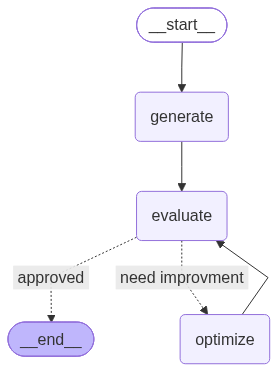

In [39]:
from IPython.display import Image, display
display(Image(workflow.get_graph().draw_mermaid_png()))

In [60]:
initial_state = {
    "topic": "Indian IT Market",
    "Iteration" : 1,
    "maxIteration": 3
}

workflow.invoke(initial_state)

{'topic': 'Indian IT Market',
 'tweet': [{'type': 'text',
   'text': 'The Indian IT market is just a massive Mexican standoff where every company demands you join tomorrow while holding their own employees hostage for 90 days.',
   'extras': {'signature': 'Eo8tCowtAWkUfRO1RGS0eAtxnX35FrmbrmfyuYsIrNIJmLzbBQ+qEhBBJDBSJnReWjz3+TQPDfiVJs2atA19A20K1yTE/nt9eEqyg4LO1VRD6h9Y44GxObVNaK1lOb5BCBmY9qa+b8g7WlXWRbrmWSU94tr3725GBAIJT5g7HxP3/Kg5TZikudjw33DzPB+Utbl3k6ghlDS841mFsOdLAgadKnFtq3qfDw2lxXDctmf8DjzqZP6beOE3vSN3pOrNkp17XCZir9G/iaJ6kXjDW2gc/3Ir7UhjJzX9B3k9PkXvEjc4LGsgB7vA/11rtuqMnkT/KraQWJLqn3R9x7k175kFGhlHF695Ipq6VNK38TUfwaQqbgtzEcxaZv0vg8PhIzgFhL6r7aauQYOuPFq3F/zo3QSJk1xzDCK+ltt3ylVrF/4Q01focoxLg25IGuhsw9sKx6Tz7NPE/xGvnMQyMaJZxW0Nzm1SieGWbAZj7+mKJ6Tv/KW1GoWrjrhJDo2H3iWlcJ/x7pduISg7kjubtuad6BrB9Zz4ZauwEdnNiaivqFvuz8UYxjepE45wcdyELX7MWajW2ps6uIe+4e6kKkjy0mr3w6fIRf0aLujn3BMdP41Q97G/kBtSWWGZG0prELgS6oo0qRMErFLDHMTP61UzHgNq375iNW/LEoRQgmi5XH0GHhvxwKSfJmhCdEqwjcJFhENr4H2TpnIosBHHwtFyJiZJYioT1Tekpoe